In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from neural_network.utils import build_covariance_matrix
from neural_network.trainer import TwoDimensionalTrainer
from neural_network.config import MarketParams, ModelConfig
from neural_network.payoff import PutMaxTwoAssets, PutMinTwoAssets, PutProductTwoAssets

In [2]:
S0 = 1.0
r = 0.1

sigma = np.array([
    [0.4, 0.3],
    [0.3, 0.5]
])

K = 1.0
T = 1.0
S_min = 0.0
S_max = 3 * K

market_params = MarketParams(S0=S0, r=r, sigma=sigma, K=K, T=T, S_min=S_min, S_max=S_max)

In [3]:
input_size = 3
hidden_sizes = [32, 64, 32]
output_size = 1
activation = nn.ReLU()
learning_rate = 0.001
model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate
)

In [4]:
put_max = PutMaxTwoAssets()
trainer_max = TwoDimensionalTrainer(model_config, market_params, put_max, 67)
trainer_max.train(num_samples=1000, max_iterations=10000, tol=1e-6)

Iteration 0, Loss: 1.019377589225769
Iteration 100, Loss: 0.006684678141027689
Converged at iteration 151


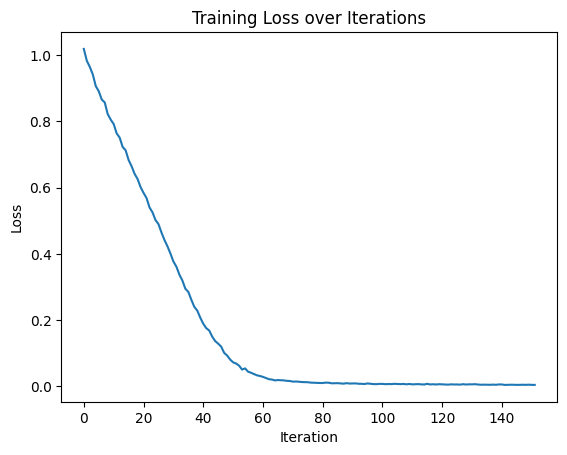

In [5]:
trainer_max.plot_losses()

In [6]:
trainer_max.predict(0, 1, 1).item()

0.042351678013801575

In [7]:
put_min = PutMinTwoAssets()
trainer_min = TwoDimensionalTrainer(model_config, market_params, put_min, 67)
trainer_min.train(num_samples=1000, max_iterations=10000, tol=1e-6)

Iteration 0, Loss: 2.539588451385498
Iteration 100, Loss: 0.022239793092012405
Iteration 200, Loss: 0.0026214211247861385
Iteration 300, Loss: 0.0012666973052546382
Converged at iteration 323


In [ ]:
trainer_min.predict(0, 1, 1).item()

In [ ]:
S0 = 5.0
r = 0.1
sigma = {'sigma1': 0.4, 'sigma2': 0.4, 'rho': 0.3}
K = 25.0
T = 1.0
S_min = 0.0
S_max = np.sqrt(3 * K)

market_params = MarketParams(S0=S0, r=r, sigma=sigma, K=K, T=T, S_min=S_min, S_max=S_max)

In [ ]:
put_product = PutProductTwoAssets()
trainer_product = TwoDimensionalTrainer(model_config, market_params, put_product, 67)
trainer_product.train(num_samples=1000, max_iterations=10000, tol=1e-4)

In [ ]:
trainer_product.plot_losses()

In [ ]:
trainer_product.predict(1, 5, 5).item()